In [1]:
from datasets import load_dataset
dataset = load_dataset("potsawee/wiki_bio_gpt3_hallucination")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.45k [00:00<?, ?B/s]

data/evaluation-00000-of-00001-e91191b8f(…):   0%|          | 0.00/2.56M [00:00<?, ?B/s]

Generating evaluation split:   0%|          | 0/238 [00:00<?, ? examples/s]

In [2]:
dataset

DatasetDict({
    evaluation: Dataset({
        features: ['gpt3_text', 'wiki_bio_text', 'gpt3_sentences', 'annotation', 'wiki_bio_test_idx', 'gpt3_text_samples'],
        num_rows: 238
    })
})

In [14]:
data.to_csv('processed_data.csv', index=False)

from google.colab import files
files.download('processed_data.csv')

array(['minor_inaccurate', 'minor_inaccurate', 'minor_inaccurate',
       'major_inaccurate', 'major_inaccurate', 'major_inaccurate',
       'major_inaccurate'], dtype=object)

# Token Probability Approach

In [ ]:
SEED = 4

## Deep Learning Installations

These are the libraries needed to run this notebook

In [ ]:
%pip install transformers datasets evaluate rouge_score
%pip install --upgrade huggingface_hub
"""
%pip install accelerate -U
%pip install transformers[torch]
%pip install sentencepiece
%pip install google
%pip install protobuf
"""

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=1bc7c7e0b09ac109f51e3fdb791a293a184faf268667884564fa4c343683dd89
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 27.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.17.0
    Uninstalling huggingface_hub-1.17.0:
      Successfully uninstalled huggingface_hub-1.17.0


'\n%pip install accelerate -U\n%pip install transformers[torch]\n%pip install sentencepiece\n%pip install google\n%pip install protobuf\n'

## Libraries

In [ ]:
SEED = 4

In [ ]:
from datasets import load_dataset
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import DataCollatorForSeq2Seq
from transformers import pipeline
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM
import numpy as np
np.random.seed(SEED)
import pandas as pd
import evaluate
import random
import json
import matplotlib.pyplot as plt
import seaborn as sns


## Loading and Cleaning the Data

Here I have used HaluEval 2.0 dataset which comes under the "general Q-A" dataset category.

### Dataset Names:
- summarization
- dialogue
- qa
- general


In [ ]:
## As a recomendation keep these two with the same naming if you do not want to change many things
datasetName = "general"
task = datasetName

In [ ]:
import requests

base_url = "https://raw.githubusercontent.com/RUCAIBox/HaluEval-2.0/master/annotation/human_annotation/"


bio_medical = requests.get(base_url + "Bio-Medical.json").json()
education = requests.get(base_url + "Education.json").json()
finance = requests.get(base_url + "Finance.json").json()
open_domain = requests.get(base_url + "Open-Domain.json").json()
science = requests.get(base_url + "Science.json").json()

In [ ]:
finance[0]

{'id': 50,
 'user_query': "Will my wife's business losses offset my income on a joint tax return?",
 'chatgpt_response': 'In some cases, it may be possible for your wife\'s business losses to offset your income on a joint tax return. However, this would depend on several factors, such as the type of business, the amount of losses, and your overall tax situation.\nIf your wife operates a business as a sole proprietorship, partnership, or LLC, the losses from her business may be deductible against your joint income on your tax return. This is known as a "pass-through" deduction, where the business losses are passed through to your personal tax return.\nHowever, if your wife\'s business operates as a corporation, the losses are typically not directly deductible on your personal tax return. In this case, the losses would be carried forward and used to offset future profits of the corporation.\nIt\'s important to consult with a tax professional or accountant who can review your specific sit

### Saving the above file with combined domains

In [ ]:
def process_and_save(datasets_dict):

    # 1. Add domain column
    for name, df in datasets_dict.items():
        df["domain"] = name

    # 2. Merge all datasets
    data = pd.concat(datasets_dict.values(), ignore_index=True)

    # 3. Create hallucination label
    def get_label(judges):
        if not isinstance(judges, list) or len(judges) == 0:
            return "unknown"
        judges = [str(j).strip().lower() for j in judges]
        return "yes" if "false" in judges else "no"

    data["hallucination_label"] = data["human_judge"].apply(get_label)

    # 4. Keep only required columns
    data = data[[
        "id",
        "user_query",
        "chatgpt_response",
        "hallucination_label",
        "domain"
    ]]

    # 5. Shuffle
    data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return data

In [ ]:
import pandas as pd

datasets = {
    "education": pd.DataFrame(education),
    "bio_medical": pd.DataFrame(bio_medical),
    "finance": pd.DataFrame(finance),
    "open_domain": pd.DataFrame(open_domain),
    "science": pd.DataFrame(science)
}

data = process_and_save(datasets)

### Data Statistics

In [ ]:
data.head()

,id,user_query,chatgpt_response,hallucination_label,domain
0,2083,What is the year that both Gauhar Ali and Ifti...,Gauhar Ali and Iftikhar Ahmed have never been ...,yes,open_domain
1,3264,"In a reverse split, what happens to odd lots?","In a reverse stock split, odd lots typically r...",yes,finance
2,3533,Elijah Connor was part of the spin-off of what...,Elijah Connor was part of the spin-off of the ...,yes,open_domain
3,4063,Which filmmaker has directed more feature film...,Stephen Hopkins has directed more feature film...,no,open_domain
4,2371,“International credit report” for French natio...,"As of my knowledge in August 2021, there is no...",no,finance


In [ ]:
len(data)

1000

domain
open_domain    200
finance        200
science        200
education      200
bio_medical    200
Name: count, dtype: int64
domain
open_domain    20.0
finance        20.0
science        20.0
education      20.0
bio_medical    20.0
Name: count, dtype: float64


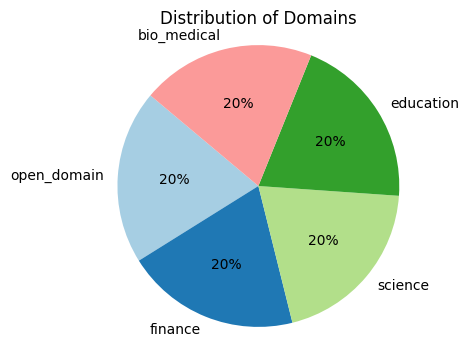

In [ ]:
# Get the counts of each unique value in 'domain'
domain_counts = data['domain'].value_counts()
domain_percent = domain_counts/len(data) * 100

print(domain_counts)
print(domain_percent)


domain_counts = data['domain'].value_counts()


plt.figure(figsize=(4, 4))
plt.pie(domain_counts, labels=domain_counts.index, autopct='%1.f%%', startangle=140, colors= plt.cm.Paired.colors)
plt.title('Distribution of Domains')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

hallucination_label
yes        896
no          80
unknown     24
Name: count, dtype: int64
hallucination_label
yes        89.6
no          8.0
unknown     2.4
Name: count, dtype: float64


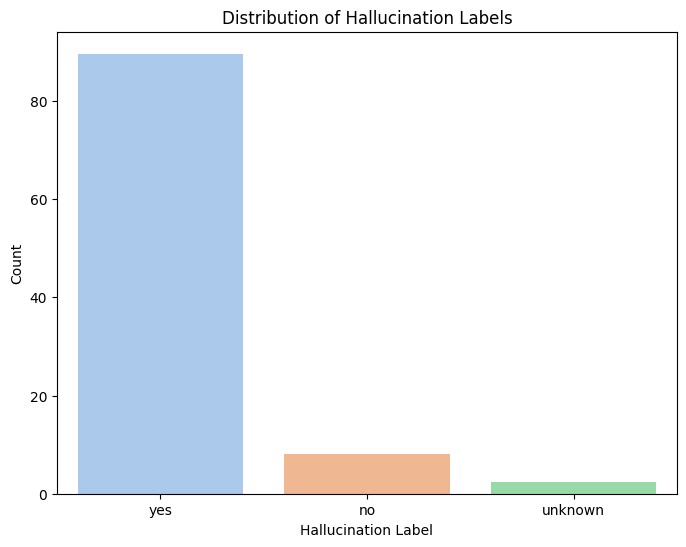

In [ ]:
# Get the counts of each unique value in 'hallucination_label'
hallucination_counts = data['hallucination_label'].value_counts()
hallucination_percent = hallucination_counts/len(data) * 100

print(hallucination_counts)
print(hallucination_percent)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=hallucination_percent.index, y=hallucination_percent.values, hue=hallucination_counts.index, palette='pastel', legend=False)
plt.title('Distribution of Hallucination Labels')
plt.xlabel('Hallucination Label')
plt.ylabel('Count')
plt.show()

### Hallucination Labels by Domain

In [ ]:
hallucination_by_domain = data.groupby('domain')['hallucination_label'].value_counts().unstack(fill_value=0)
display(hallucination_by_domain)

hallucination_label,no,unknown,yes
domain,,,
bio_medical,5,9,186
education,17,3,180
finance,46,1,153
open_domain,5,10,185
science,7,1,192


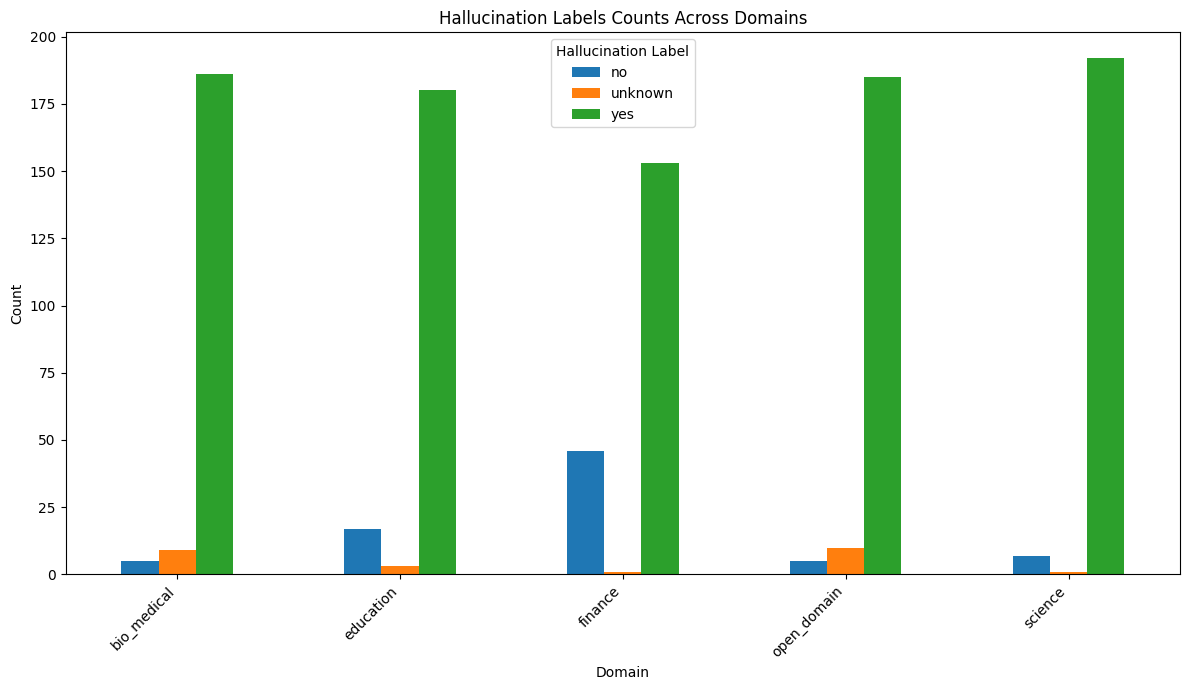

In [ ]:
hallucination_by_domain.plot(kind='bar', figsize=(12, 7))
plt.title('Hallucination Labels Counts Across Domains')
plt.xlabel('Domain')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Hallucination Label')
plt.tight_layout()
plt.show()

In [ ]:
data = data[data['hallucination_label'] != 'unknown']

# Display the new counts to verify the removal
print(data['hallucination_label'].value_counts())

hallucination_label
yes    896
no      80
Name: count, dtype: int64


In [ ]:
hallucination_by_domain = data.groupby('domain')['hallucination_label'].value_counts().unstack(fill_value=0)
display(hallucination_by_domain)

hallucination_label,no,yes
domain,,
bio_medical,5,186
education,17,180
finance,46,153
open_domain,5,185
science,7,192


In [ ]:
data.head()

,id,user_query,chatgpt_response,hallucination_label,domain
0,2083,What is the year that both Gauhar Ali and Ifti...,Gauhar Ali and Iftikhar Ahmed have never been ...,yes,open_domain
1,3264,"In a reverse split, what happens to odd lots?","In a reverse stock split, odd lots typically r...",yes,finance
2,3533,Elijah Connor was part of the spin-off of what...,Elijah Connor was part of the spin-off of the ...,yes,open_domain
3,4063,Which filmmaker has directed more feature film...,Stephen Hopkins has directed more feature film...,no,open_domain
4,2371,“International credit report” for French natio...,"As of my knowledge in August 2021, there is no...",no,finance


Data saved to processed_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Token Size of Chat gpt response

In [ ]:
data['chatgpt_response_length'] = data['chatgpt_response'].str.split().apply(len)
#display(data.head())

average_response_length_by_domain = data.groupby('domain')['chatgpt_response_length'].mean().sort_values(ascending=False)
display(average_response_length_by_domain)

,chatgpt_response_length
domain,
science,280.120603
finance,187.763819
bio_medical,125.052356
education,100.771574
open_domain,19.073684


/tmp/ipykernel_1436/2527565532.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_response_length_by_domain.index, y=average_response_length_by_domain.values, palette='viridis')


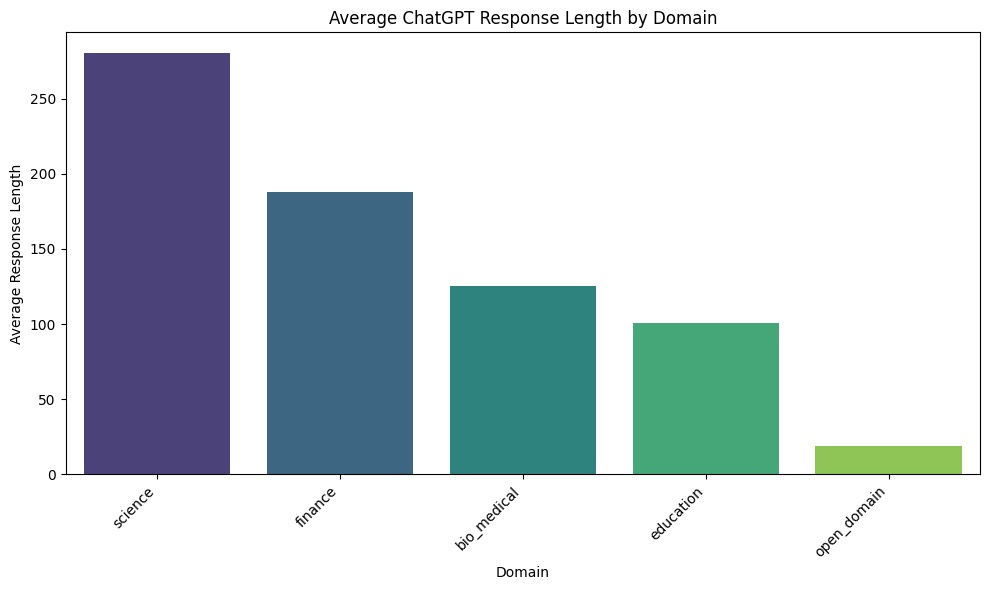

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=average_response_length_by_domain.index, y=average_response_length_by_domain.values, palette='viridis')
plt.title('Average ChatGPT Response Length by Domain')
plt.xlabel('Domain')
plt.ylabel('Average Response Length')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Balancing the classes from dataset

In [ ]:
data = data[data["hallucination_label"] != "unknown"]

df_yes = data[data["hallucination_label"] == "yes"]
df_no  = data[data["hallucination_label"] == "no"]

n = len(df_no)

data = pd.concat([
    df_yes.sample(n=n, random_state=SEED),
    df_no
]).sample(frac=1, random_state=SEED)  # shuffle

In [ ]:
data.head()

,id,user_query,chatgpt_response,hallucination_label,domain,chatgpt_response_length
256,224,How to categorize shared income?,Shared income can be categorized in different ...,yes,finance,352
713,5173,"according to this strategy , if you win your f...","According to the strategy that you mentioned, ...",no,education,25
252,2343,Where can I find the dividend history for a st...,You can find the dividend history for a stock ...,yes,finance,192
586,2321,How does the bank/IRS know whether a bank tran...,"When a bank transfer of over $14k occurs, the ...",no,finance,241
659,1456,What physician and biologist became well-known...,The physician and biologist who became well-kn...,yes,open_domain,29


In [ ]:
len(data)

160

hallucination_label
yes    80
no     80
Name: count, dtype: int64
hallucination_label
yes    50.0
no     50.0
Name: count, dtype: float64


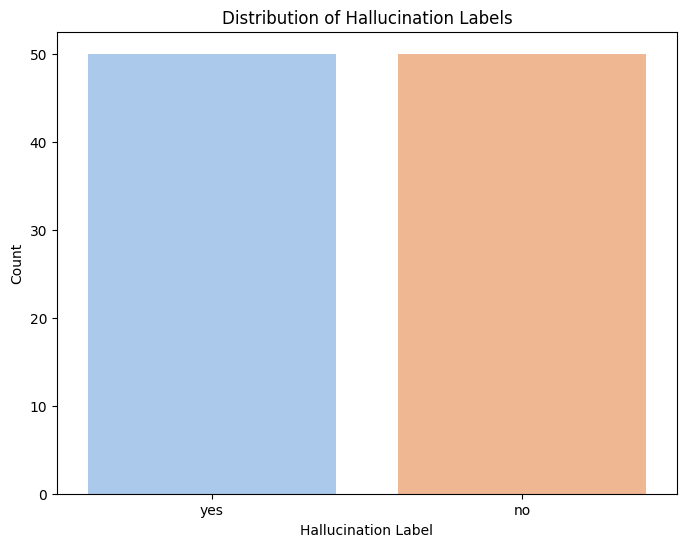

In [ ]:
# Get the counts of each unique value in 'hallucination_label'
hallucination_counts = data['hallucination_label'].value_counts()
hallucination_percent = hallucination_counts/len(data) * 100

print(hallucination_counts)
print(hallucination_percent)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=hallucination_percent.index, y=hallucination_percent.values, hue=hallucination_counts.index, palette='pastel', legend=False)
plt.title('Distribution of Hallucination Labels')
plt.xlabel('Hallucination Label')
plt.ylabel('Count')
plt.show()

domain
finance        60
education      34
bio_medical    27
science        21
open_domain    18
Name: count, dtype: int64
domain
finance        37.500
education      21.250
bio_medical    16.875
science        13.125
open_domain    11.250
Name: count, dtype: float64


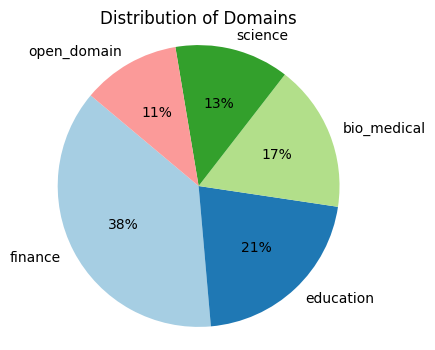

In [ ]:
# Get the counts of each unique value in 'domain'
domain_counts = data['domain'].value_counts()
domain_percent = domain_counts/len(data) * 100

print(domain_counts)
print(domain_percent)


domain_counts = data['domain'].value_counts()


plt.figure(figsize=(4, 4))
plt.pie(domain_counts, labels=domain_counts.index, autopct='%1.f%%', startangle=140, colors= plt.cm.Paired.colors)
plt.title('Distribution of Domains')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
data['chatgpt_response_length'] = data['chatgpt_response'].str.split().apply(len)
#display(data.head())

average_response_length_by_domain = data.groupby('domain')['chatgpt_response_length'].mean().sort_values(ascending=False)
display(average_response_length_by_domain)

,chatgpt_response_length
domain,
science,281.428571
finance,207.400000
bio_medical,97.555556
education,63.617647
open_domain,25.944444


## Setting Device to use the GPU

We use the T4 GPU in Colab since the heaviest computation for us is the inference of the LLM-Evaluator. Therefore, T4 seem as the better fit.

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Generic LLMModel class to reuse the functionality of extracting the features.


In [ ]:
from transformers import BartForConditionalGeneration, BartTokenizer
from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import BartForConditionalGeneration, PegasusForConditionalGeneration
from transformers import LEDForConditionalGeneration, LEDTokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import LlamaForCausalLM, LlamaTokenizer

import torch
import torch.nn.functional as F
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


class LLMModel:
    def __init__(self):
        self.model = self.model.to(device)
        pass

    def getName(self) -> str:
        return self.model_name

    def getSanitizedName(self) -> str:
        return self.model_name.replace("/", "__")

    def generate(self, inpt):
        pass

    # Move in future commits this method to an utils.py
    def truncate_string_by_len(self, s, truncate_len):
        words = s.split()
        truncated_words = words[:-truncate_len] if truncate_len > 0 else words
        return " ".join(truncated_words)

    # Method to get the vocabulary probabilities of the LLM for a given token on the generated text from LLM-Generator
    def getVocabProbsAtPos(self, pos, token_probs):
        sorted_probs, sorted_indices = torch.sort(token_probs[pos, :], descending=True)
        return sorted_probs

    def getMaxLength(self):
        return self.model.config.max_position_embeddings

    # By default knowledge is the empty string. If you want to add extra knowledge you can do it like in the cases of the qa_data.json and dialogue_data.json
    def extractFeatures(
        self,
        knowledge="",
        conditionted_text="",
        generated_text="",
        features_to_extract={},
    ):
        self.model.eval()

        total_len = len(knowledge) + len(conditionted_text) + len(generated_text)
        truncate_len = max(total_len - self.tokenizer.model_max_length, 0) # here it should be max

        knowledge_tokens = len(self.tokenizer.tokenize(knowledge))
        conditioned_tokens = len(self.tokenizer.tokenize(conditionted_text))
        generated_tokens = len(self.tokenizer.tokenize(generated_text))

        total_len = (knowledge_tokens + conditioned_tokens + generated_tokens)
        truncate_len = max(total_len - self.tokenizer.model_max_length,0)


        # Truncate knowledge in case is too large
        knowledge = self.truncate_string_by_len(knowledge, truncate_len // 2)
        # Truncate text_A in case is too large
        conditionted_text = self.truncate_string_by_len(
            conditionted_text, truncate_len - (truncate_len // 2)
        )

        inputs = self.tokenizer(
            [knowledge + conditionted_text + generated_text],
            return_tensors="pt",
            max_length=self.getMaxLength(),
            truncation=True,
        )

        for key in inputs:
            inputs[key] = inputs[key].to(device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits

        probs = F.softmax(logits, dim=-1)
        probs = probs.to(device)

        tokens_generated_length = len(self.tokenizer.tokenize(generated_text))
        start_index = logits.shape[1] - tokens_generated_length
        conditional_probs = probs[0, start_index :]

        token_ids_generated = inputs["input_ids"][0, start_index :].tolist()
        token_probs_generated = [
            conditional_probs[i, tid].item()
            for i, tid in enumerate(token_ids_generated)
        ]

        tokens_generated = self.tokenizer.convert_ids_to_tokens(token_ids_generated)

        minimum_token_prob = min(token_probs_generated)
        average_token_prob = sum(token_probs_generated) / len(token_probs_generated)

        maximum_diff_with_vocab = -1
        minimum_vocab_extreme_diff = 100000000000

        if features_to_extract["MDVTP"] == True or features_to_extract["MMDVP"] == True:
            size = len(token_probs_generated)
            for pos in range(size):
                vocabProbs = self.getVocabProbsAtPos(pos, conditional_probs)
                maximum_diff_with_vocab = max(
                    [
                        maximum_diff_with_vocab,
                        self.getDiffVocab(vocabProbs, token_probs_generated[pos]),
                    ]
                )
                minimum_vocab_extreme_diff = min(
                    [
                        minimum_vocab_extreme_diff,
                        self.getDiffMaximumWithMinimum(vocabProbs),
                    ]
                )

        # allFeatures = [minimum_token_prob, average_token_prob, maximum_diff_with_vocab, minimum_vocab_extreme_diff]

        allFeatures = {
            "mtp": minimum_token_prob,
            "avgtp": average_token_prob,
            "MDVTP": maximum_diff_with_vocab,
            "MMDVP": minimum_vocab_extreme_diff,
        }

        selectedFeatures = {}
        for key, feature in features_to_extract.items():
            if feature == True:
                selectedFeatures[key] = allFeatures[key]

        return selectedFeatures

    def getDiffVocab(self, vocabProbs, tprob):
        return (vocabProbs[0] - tprob).item()

    def getDiffMaximumWithMinimum(self, vocabProbs):
        return (vocabProbs[0] - vocabProbs[-1]).item()

## Definition of the specific Models

In [ ]:
class Gemma(LLMModel):
    def __init__(self):
        self.model_name = "google/gemma-7b-it"
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name
        )
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class LLama(LLMModel):
    def __init__(self):
        self.model_name = "meta-llama/Llama-2-7b-chat-hf"
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
        )
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=1024, return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class Opt(LLMModel):
    def __init__(self):
        self.model_name = "facebook/opt-6.7b"
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class Gptj(LLMModel):
    def __init__(self):
        self.model_name = "EleutherAI/gpt-j-6B"
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class BartCNN(LLMModel):
    def __init__(self):
        self.model_name = "facebook/bart-large-cnn"
        self.model = BartForConditionalGeneration.from_pretrained(self.model_name)
        self.tokenizer = BartTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary

class GPT2Generator(LLMModel):
    def __init__(self):
        self.model_name = "gpt2-large"
        self.model = GPT2LMHeadModel.from_pretrained(self.model_name)
        self.tokenizer = GPT2Tokenizer.from_pretrained(self.model_name)
        super().__init__()

    def generate(self, inpt):
        inputs = self.tokenizer.encode(
            inpt, return_tensors="pt", max_length=self.getMaxLength(), truncation=True
        )
        output_ids = self.model.generate(
            inputs, max_length=1024, num_return_sequences=1
        )
        output = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        return output


class LED(LLMModel):
    def __init__(self):
        self.model_name = "allenai/led-large-16384-arxiv"
        self.model = LEDForConditionalGeneration.from_pretrained(self.model_name)
        self.tokenizer = LEDTokenizer.from_pretrained(self.model_name)
        super().__init__()

    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary

## Features_to_extract
The Dictionary `features_to_extract` defines which features will be use in this experiment.

### Features Meaning:

- `mtp` : Take the minimum of the probabilities that the LLM_E gives to the tokens on the generated-text.
- `avgtp` : Take the average of the probabilities that the LLM_E
gives to the tokens on the generated-text.
- `MDVTP` : Take the maximum from all the differences
between the token with the highest probability
according to LLM_E at position i and the
assigned probability from LLM_E to the token at position i in the generated_text.
- `MMDVP` : Take the maximum from all the differences between the token with the highest probability according to $LLM_E$ at position $i$ ($v^*$) and the token with the lowest probability according to $LLM_E$ at position $i$ ($v^-$).


In [ ]:
feature_to_extract = 'all'

available_features_to_extract = ["mtp", "avgtp", "MDVTP", "MMDVP"]
if feature_to_extract == 'all':
    features_to_extract = {
        feature: True for feature in available_features_to_extract
    }
else:
    features_to_extract = {
        feature: True if feature == feature_to_extract else False
        for feature in available_features_to_extract
    }

features_to_extract

{'mtp': True, 'avgtp': True, 'MDVTP': True, 'MMDVP': True}

## Cleaning Cache on GPU to save memory

In [ ]:
import torch
import gc

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
gc.collect()
torch.cuda.empty_cache()

## This cell is to instantiate the model you intend to use for the experiment

In [ ]:
# model = BartCNN()
# model = LED()
model = GPT2Generator()
# model = LLama()
# model = Gemma()
# model = Opt()
# model = Gptj()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## Train-Test Spliting

### As expected from previous cells the task string expected are:
- `summarization`
- `qa`
- `dialogue`
- `general`

In [ ]:
import random


# Load the data depending on the task
def loadRowData(taskName, row, includeKnowledge=False):
    if taskName == "summarization":
        return "", row["document"], row["right_summary"], row["hallucinated_summary"]
    elif taskName == "qa":
        if includeKnowledge:
            return (
                row["knowledge"],
                row["question"],
                row["right_answer"],
                row["hallucinated_answer"],
            )
        else:
            return "", row["question"], row["right_answer"], row["hallucinated_answer"]

    elif taskName == "dialogue":
        if includeKnowledge:
            return (
                row["knowledge"],
                row["dialogue_history"],
                row["right_response"],
                row["hallucinated_response"],
            )
        else:
            return (
                "",
                row["dialogue_history"],
                row["right_response"],
                row["hallucinated_response"],
            )

    elif taskName == "general":
        return (
            "",
            row["user_query"],
            row["chatgpt_response"],
            row["hallucination_label"],
        )

    else:
        raise Exception("Task not supported")


# Adapt the dataset to have a data point of conditioned-text with right-generation and another with the same conditioned-text and tha hallucinated answer.
def adaptDataset(data, taskName):
    datasetAdapted = None
    if taskName == "general":
        # There is data point that is filling the <mask> token but that gives error with some LLMs
        datasetAdapted = [
            (
                (knowledge, document, response, 1)
                if hallu == "yes"
                else (knowledge, document, response, 0)
            )
            for knowledge, document, response, hallu in data
            if "<mask>" not in document and "<mask>" not in response
        ]

    elif taskName == "summarization" or taskName == "qa" or taskName == "dialogue":
        datasetAdapted = [
            (knowledge, document, right, 1)
            for knowledge, document, right, hallu in data
        ] + [
            (knowledge, document, hallu, 0)
            for knowledge, document, right, hallu in data
        ]

    else:
        raise Exception("Task not supported")

    #random.shuffle(datasetAdapted)
    return datasetAdapted

In [ ]:
def splitDataset(
    data: pd.DataFrame,
    taskName: str,
    trainingSize: int,
    valSize: int,
    includeKnowledge=False,
):

    dataset = []
    for _, row in data.iterrows():
        knowledge, text, right, hallu = loadRowData(taskName, row, includeKnowledge)
        dataset.append((knowledge, text, right, hallu))

    #random.shuffle(dataset)

    dataset_train = dataset[:trainingSize]  # Take only trainingSize
    dataset_val = (
        []
    )  # dataset[trainingSize:trainingSize + valSize] # Take only trainingSize
    dataset_test = dataset[trainingSize:]  # Take the rest as testing

    datasetAdaptedTrain = adaptDataset(dataset_train, taskName)
    datasetAdaptedValidation = adaptDataset(dataset_val, taskName)
    datasetAdaptedTest = adaptDataset(dataset_test, taskName)

    X_train = [(x, q, y) for x, q, y, _ in datasetAdaptedTrain]
    Y_train = [z for _, _, _, z in datasetAdaptedTrain]

    X_val = [(x, q, y) for x, q, y, _ in datasetAdaptedValidation]
    Y_val = [z for _, _, _, z in datasetAdaptedValidation]

    X_test = [(x, q, y) for x, q, y, _ in datasetAdaptedTest]
    Y_test = [z for _, _, _, z in datasetAdaptedTest]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [ ]:
includeKnowledge = True
includeConditioned = True

In [ ]:
"""
X_train, Y_train, X_val, Y_val, X_test, Y_test = splitDataset(
    data, task, 2, 0, includeKnowledge=includeKnowledge
)
"""

'\nX_train, Y_train, X_val, Y_val, X_test, Y_test = splitDataset(\n    data, task, 2, 0, includeKnowledge=includeKnowledge\n)\n'

In [ ]:
from sklearn.model_selection import train_test_split

# for now no validation

train_df, test_df = train_test_split(
    data,
    test_size=0.2,  # 20% test
    stratify=data["hallucination_label"],  # VERY important
    random_state=SEED
)


In [ ]:
def df_to_XY(df):
    X, Y = [], []
    for _, row in df.iterrows():
        X.append(("", row["user_query"], row["chatgpt_response"]))
        Y.append(1 if row["hallucination_label"] == "yes" else 0)
    return X, Y

X_train, Y_train = df_to_XY(train_df)
X_test, Y_test = df_to_XY(test_df)
#X_val, Y_val = df_to_XY(val_df)

X_val = []
Y_val = []

In [ ]:
print(len(X_train), len(Y_train))
print(len(X_val), len(Y_val))
print(len(X_test), len(Y_test))  # verify the sizes look right

128 128
0 0
32 32


## To Save the separation if needed

In [ ]:

train_df = pd.DataFrame(
    {
        "Knowledge": [x[0] for x in X_train],
        "Conditioned Text": [x[1] for x in X_train],
        "Generated Text": [x[2] for x in X_train],
        "Label": Y_train,
    }
)

val_df = pd.DataFrame(
    {
        "Knowledge": [x[0] for x in X_val],
        "Conditioned Text": [x[1] for x in X_val],
        "Generated Text": [x[2] for x in X_val],
        "Label": Y_val,
    }
)

test_df = pd.DataFrame(
    {
        "Knowledge": [x[0] for x in X_test],
        "Conditioned Text": [x[1] for x in X_test],
        "Generated Text": [x[2] for x in X_test],
        "Label": Y_test,
    }
)

"""
#Export to CSV
if includeKnowledge:
    train_df.to_csv(output_path / (task + '_knowledge_train_data.csv'), index=False)
    test_df.to_csv(output_path / (task + '_knowledge_test_data.csv'), index=False)
else:
    train_df.to_csv(output_path / (task + '_train_data.csv'), index=False)
    val_df.to_csv(output_path / (task + '_val_data.csv'), index=False)
    test_df.to_csv(output_path / (task + '_test_data.csv'), index=False)

"""

"\n#Export to CSV\nif includeKnowledge:\n    train_df.to_csv(output_path / (task + '_knowledge_train_data.csv'), index=False)\n    test_df.to_csv(output_path / (task + '_knowledge_test_data.csv'), index=False)\nelse:\n    train_df.to_csv(output_path / (task + '_train_data.csv'), index=False)\n    val_df.to_csv(output_path / (task + '_val_data.csv'), index=False)\n    test_df.to_csv(output_path / (task + '_test_data.csv'), index=False)\n\n"

In [ ]:
def getXY(df: pd.DataFrame, includeKnowledge=True, includeConditioned=True):
    X = []
    Y = []

    # Iterate over rows using itertuples
    for _, row in df.iterrows():
        x, c, g = (
            row["Knowledge"] if includeKnowledge else "",
            row["Conditioned Text"] if includeConditioned else "",
            row["Generated Text"],
        # g = (row["Generated Text"]
        )
        y = row["Label"]

        # Append values to respective lists
        X.append((x, c, g))
        # X.append(g)
        Y.append(y)
    return X, Y

In [ ]:
X_train, Y_train = getXY(
    train_df, includeKnowledge=includeKnowledge, includeConditioned=includeConditioned
)
X_val, Y_val = getXY(
    val_df, includeKnowledge=includeKnowledge, includeConditioned=includeConditioned
)
X_test, Y_test = getXY(
    test_df, includeKnowledge=includeKnowledge, includeConditioned=includeConditioned
)

In [ ]:
print(len(X_train), len(Y_train))
print(len(X_val), len(Y_val))
print(len(X_test), len(Y_test))  # verify the sizes look right

128 128
0 0
32 32


In [ ]:
X_test[0]

('',
 'looking at the periodic table , which of the 32 isotopes of tantalum do you think is most abundant in nature ?',
 'The most abundant isotope of tantalum in nature is tantalum-181 (Ta-181).')

In [ ]:
Y_test[0]

0

## Extracting the features for the Training Data

In [ ]:
import torch
from tqdm import tqdm

torch.cuda.manual_seed(SEED)

def extract_features(
    knowledge: str,
    conditioned_text: str,
    generated_text: str,
    features_to_extract: dict[str, bool],
):
    return model.extractFeatures(
        knowledge, conditioned_text, generated_text, features_to_extract
    )


X_train_features_maps = []

for knowledge, conditioned_text, generated_text in tqdm(X_train, desc="Processing"):
    X_train_features_maps.append(
        extract_features(
            knowledge, conditioned_text, generated_text, features_to_extract
        )
    )
    torch.cuda.empty_cache()  # Clean cache in every step for memory saving.

Processing: 100%|██████████| 128/128 [00:26<00:00,  4.79it/s]


In [ ]:
len(X_train_features_maps)

128

In [ ]:
X_train_features_maps[0] # for first datapoint

{'mtp': 3.3525575978549105e-12,
 'avgtp': 0.00307226419402644,
 'MDVTP': 0.9999657869338989,
 'MMDVP': 0.03498667851090431}

In [ ]:
X_train_features = [list(dic.values()) for dic in X_train_features_maps]

In [ ]:
len(X_train_features) # 4 features for each datapoint

128

In [ ]:
X_train_features[0]

[3.3525575978549105e-12,
 0.00307226419402644,
 0.9999657869338989,
 0.03498667851090431]

In [ ]:
pd.DataFrame(X_train_features).describe()

,0,1,2,3
count,1.280000e+02,128.000000,128.000000,128.000000
mean,2.469468e-07,0.002143,0.994452,0.058124
std,1.640233e-06,0.002325,0.023820,0.028109
min,1.428173e-13,0.000044,0.754685,0.017904
25%,8.815774e-11,0.000224,0.997554,0.038716
50%,1.103178e-09,0.002273,0.999551,0.053532
75%,1.322060e-08,0.003278,0.999889,0.070258
max,1.773658e-05,0.012077,0.999994,0.195716


The features are not in the same scale, so I will Normalize them using StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_features = scaler.fit_transform(X_train_features)

In [ ]:
import pandas as pd

df = pd.DataFrame(
    X_train_features,
    columns=["mtp","avgtp","MDVTP","MMDVP"]
)

print(df.corr())

            mtp     avgtp     MDVTP     MMDVP
mtp    1.000000 -0.111287 -0.296503  0.184057
avgtp -0.111287  1.000000  0.177366 -0.355349
MDVTP -0.296503  0.177366  1.000000 -0.141002
MMDVP  0.184057 -0.355349 -0.141002  1.000000


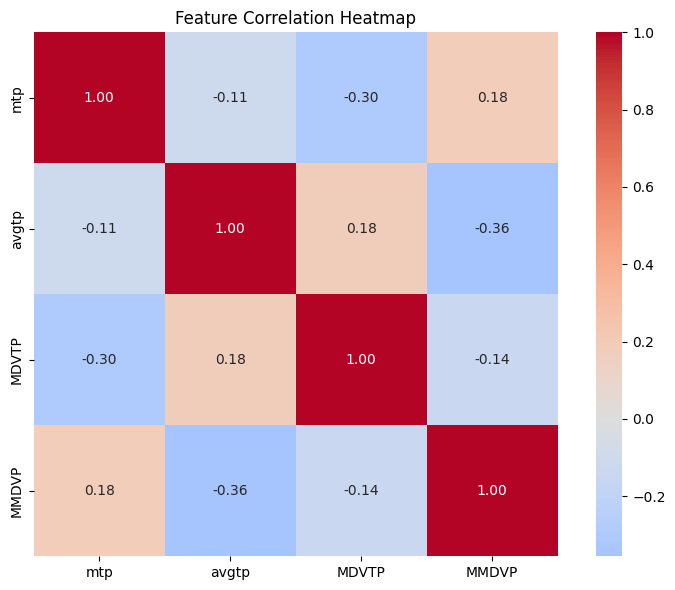

In [ ]:
df = pd.DataFrame(
    X_train_features,
    columns=["mtp", "avgtp", "MDVTP", "MMDVP"]
)

corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame(X_train_features).describe()

,0,1,2,3
count,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02
mean,6.938894e-18,-6.245005e-17,-1.734723e-18,2.081668e-17
std,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00
min,-1.511474e-01,-9.063821e-01,-1.010534e+01,-1.436484e+00
25%,-1.510935e-01,-8.288919e-01,1.307300e-01,-6.931776e-01
50%,-1.504723e-01,5.585828e-02,2.149257e-01,-1.640150e-01
75%,-1.430556e-01,4.899798e-01,2.291764e-01,4.333708e-01
max,1.070479e+01,4.289815e+00,2.335933e-01,4.914163e+00


## Training Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(verbose=1, random_state=SEED)
"""
verbose=1 in logistic regression
(specifically in libraries like scikit-learn) enables the display of progress information,
such as iteration counts and loss values, during the model training process.
It is used to monitor convergence, especially during long training sessions.
"""

clf.fit(X_train_features, Y_train) # len(X_train_features) = len(Y_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


LogisticRegression(random_state=4, verbose=1)

## Evaluate accuracy of Logistic Regression on the training set

logit(p) = w1 x1 ​+ w2 x2 + w3 x3 + w4 x4 + b

In [ ]:
## they are global weights learnt from entire training data:

# if my features are on different scale:
# from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score

log_odds = clf.coef_[0] # clf.coef_[0] = clf.coef_
odds = np.exp(clf.coef_[0])


""" Safer to know the order:
feature_names = ["mtp", "avgtp", "Mpd", "mps"]

lr_features_log = dict(zip(feature_names, log_odds))
lr_features_no_log = dict(zip(feature_names, odds))
"""

lr_features_log = {k: v for k, v in zip(X_train_features_maps[0].keys(), log_odds)}
lr_features_no_log = {k: v for k, v in zip(X_train_features_maps[0].keys(), odds)}

print("log", lr_features_log)
print("no_log", lr_features_no_log)

log {'mtp': np.float64(0.34508242114671883), 'avgtp': np.float64(0.008006318669604075), 'MDVTP': np.float64(0.05203310366506386), 'MMDVP': np.float64(-0.2211993516514487)}
no_log {'mtp': np.float64(1.4121063022921223), 'avgtp': np.float64(1.0080384549460952), 'MDVTP': np.float64(1.05341061368831), 'MMDVP': np.float64(0.8015568726754707)}


## Extracting the Features of the Validation Set

In [ ]:
X_val_features_map = []

for knowledge, conditioned_text, generated_text in tqdm(X_val, desc="Processing"):
    X_val_features_map.append(
        extract_features(
            knowledge, conditioned_text, generated_text, features_to_extract
        )
    )
    torch.cuda.empty_cache()

Processing: 0it [00:00, ?it/s]


In [ ]:
X_val_features = [list(dic.values()) for dic in X_val_features_map]

## Uncomment next cell if you have a validation set and you want to see LR accuracy on it.

In [ ]:
# from sklearn.metrics import accuracy_score

# Y_Pred = clf.predict(X_val_features)

# accuracy = accuracy_score(Y_val, Y_Pred)
# print(f"Accuracy: {accuracy * 100:.2f}%")

## Extracting the Features of the Test Set

In [ ]:
from tqdm import tqdm

X_test_features_map = []

for knowledge, conditioned_text, generated_text in tqdm(X_test, desc="Processing"):
    X_test_features_map.append(
        extract_features(
            knowledge, conditioned_text, generated_text, features_to_extract
        )
    )
    torch.cuda.empty_cache()

Processing: 100%|██████████| 32/32 [00:05<00:00,  5.95it/s]


In [ ]:
X_test_features = [list(dic.values()) for dic in X_test_features_map]

In [ ]:
pd.DataFrame(X_test_features).describe()

,0,1,2,3
count,3.200000e+01,32.000000,32.000000,32.000000
mean,2.284076e-08,0.002812,0.998855,0.048047
std,1.039208e-07,0.003142,0.002223,0.027802
min,2.080105e-12,0.000107,0.989904,0.012113
25%,3.272833e-11,0.000227,0.999126,0.027052
50%,1.968061e-10,0.002710,0.999750,0.042713
75%,2.216445e-09,0.003987,0.999859,0.062417
max,5.878092e-07,0.016721,0.999973,0.147199


In [ ]:
X_test_features = scaler.transform(X_test_features)

In [ ]:
pd.DataFrame(X_test_features).describe()

,0,1,2,3
count,32.000000,32.000000,32.000000,32.000000
mean,-0.137167,0.288955,0.185557,-0.359915
std,0.063606,1.356766,0.093703,0.992954
min,-0.151146,-0.879284,-0.191677,-1.643314
25%,-0.151127,-0.827254,0.196989,-1.109772
50%,-0.151027,0.244840,0.223281,-0.550408
75%,-0.149791,0.796239,0.227885,0.153327
max,0.208630,6.295163,0.232694,3.181376


## Evaluate accuracy of the LogisticRegression on the testing set

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

Y_Pred = clf.predict(X_test_features)

lr_accuracy = accuracy_score(Y_test, Y_Pred)
print(f"Accuracy: {lr_accuracy * 100:.2f}%")

Accuracy: 65.62%


In [ ]:
y_prob = clf.predict_proba(X_test_features)[:, 1]
# Negative probabilities
y_prob_neg = 1 - y_prob

In [ ]:
metrics = {
    "lr_accuracy": accuracy_score(Y_test, Y_Pred),
    "lr_precision": precision_score(Y_test, Y_Pred),
    "lr_recall": recall_score(Y_test, Y_Pred),
    "lr_f1": f1_score(Y_test, Y_Pred),
    "lr_roc_auc": roc_auc_score(Y_test, y_prob),
    "lr_pr_auc": average_precision_score(Y_test, y_prob),
    "lr_precision_neg" : precision_score(Y_test, Y_Pred, pos_label=0),
    "lr_recall_neg" : recall_score(Y_test, Y_Pred, pos_label=0),
    "lr_f1_neg" : f1_score(Y_test, Y_Pred, pos_label=0),
    "lr_roc_auc_neg" : roc_auc_score(1 - np.array(Y_test), y_prob_neg),
    "pr_auc_neg" : average_precision_score(1 - np.array(Y_test), y_prob_neg)
}

In [ ]:
log_odds = clf.coef_[0]
pd.DataFrame(log_odds, X_train_features_maps[0].keys(), columns=["coef"]).sort_values(
    by="coef", ascending=False
)

,coef
mtp,0.345082
MDVTP,0.052033
avgtp,0.008006
MMDVP,-0.221199


In [ ]:
odds = np.exp(clf.coef_[0])
pd.DataFrame(odds, X_train_features_maps[0].keys(), columns=["coef"]).sort_values(
    by="coef", ascending=False
)

,coef
mtp,1.412106
MDVTP,1.053411
avgtp,1.008038
MMDVP,0.801557


In [ ]:
print(clf.intercept_)

[0.00924939]


In [ ]:
print(metrics)

{'lr_accuracy': 0.65625, 'lr_precision': 0.6190476190476191, 'lr_recall': 0.8125, 'lr_f1': 0.7027027027027027, 'lr_roc_auc': np.float64(0.6640625), 'lr_pr_auc': np.float64(0.5970141919778487), 'lr_precision_neg': 0.7272727272727273, 'lr_recall_neg': 0.5, 'lr_f1_neg': 0.5925925925925926, 'lr_roc_auc_neg': np.float64(0.6640625), 'pr_auc_neg': np.float64(0.7061276564670962)}


## Simple Dense NN

In [ ]:
import torch.nn as nn


class SimpleDenseNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim=1, dropout_prob=0.3):
        super(SimpleDenseNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

## Hyperparamters

In [ ]:
hidden_dim = 20
num_epochs = 100

In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
denseModel = SimpleDenseNet(
    input_dim=np.array([v for v in features_to_extract.values()]).sum(), hidden_dim = hidden_dim
).to(device)

## Code declaring and computing all the metrics to measure

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)


def compute_metrics(model, input_tensor, true_labels):
    with torch.no_grad(): # torch.no_grad : disable gradient calculation
        outputs = model(input_tensor)
        # predicted_probs = torch.sigmoid(outputs).cpu().numpy()  # last layer in forward already has sigmoid activation funtion
        predicted_probs = outputs.cpu().numpy()
        predicted = (outputs > 0.5).float().cpu().numpy()

        true_labels = true_labels.cpu().numpy()

        acc = accuracy_score(true_labels, predicted)
        precision = precision_score(true_labels, predicted)
        recall = recall_score(true_labels, predicted)
        f1 = f1_score(true_labels, predicted)

        precision_negative = precision_score(true_labels, predicted, pos_label=0)
        recall_negative = recall_score(true_labels, predicted, pos_label=0)
        f1_negative = f1_score(true_labels, predicted, pos_label=0)

        tn, fp, fn, tp = confusion_matrix(true_labels, predicted).ravel()
        roc_auc = roc_auc_score(true_labels, predicted_probs)

        P, R, thre = precision_recall_curve(true_labels, predicted_probs)
        pr_auc = auc(R, P)

        roc_auc_negative = roc_auc_score(
            1 - true_labels, 1 - predicted_probs
        )  # If predicted_probs is the probability of the positive class
        P_neg, R_neg, _ = precision_recall_curve(1 - true_labels, 1 - predicted_probs)
        pr_auc_negative = auc(R_neg, P_neg)

        return {
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "ROC AUC": roc_auc,
            "PR AUC": pr_auc,
            "Precision-Negative": precision_negative,
            "Recall-Negative": recall_negative,
            "F1-Negative": f1_negative,
            "ROC AUC-Negative": roc_auc_negative,
            "PR AUC-Negative": pr_auc_negative,
        }

## Code for training the Dense Model and getting the result of all metrics corresponding to the Testing Set.

In [ ]:
def compute_accuracy(model, input_tensor, true_labels):
    with torch.no_grad():
        outputs = model(input_tensor)
        predicted = (outputs > 0.5).float()
        correct = (predicted == true_labels).float().sum()
        accuracy = correct / len(true_labels)
        return accuracy.item()


X_train_tensor = torch.tensor(X_train_features, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1).to(device)

print(X_train_tensor.shape, Y_train_tensor.shape)

# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(denseModel.parameters(), lr=0.001)

bestValAcc = 0
# Training loop
num_epochs = num_epochs # reducing to 5000
for epoch in range(num_epochs):
    denseModel.train()
    optimizer.zero_grad()
    outputs = denseModel(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    # Compute training accuracy
    train_accuracy = compute_accuracy(denseModel, X_train_tensor, Y_train_tensor)

    # Uncomment this if you want to see how the accuracy of testing improves during the training process.
    ##Compute testing accuracy
    # X_val_tensor = torch.tensor(X_val_features, dtype=torch.float32).to(device)
    # Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32).view(-1, 1).to(device)

    # val_accuracy = compute_accuracy(denseModel, X_val_tensor, Y_val_tensor)

    # if bestValAcc < val_accuracy:
    #     bestValAcc = val_accuracy
    #     print(f'Saving model with best validation accuracy ...')
    #     torch.save(denseModel.state_dict(), 'llama-' + task + '-best-model')

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Training Accuracy: {train_accuracy:.4f}"
        )  # , "Validation Accuracy": {val_accuracy:.4f}')

torch.Size([128, 4]) torch.Size([128, 1])
Epoch [10/100], Loss: 0.6855, Training Accuracy: 0.5078
Epoch [20/100], Loss: 0.6808, Training Accuracy: 0.5859
Epoch [30/100], Loss: 0.6765, Training Accuracy: 0.5859
Epoch [40/100], Loss: 0.6721, Training Accuracy: 0.5781
Epoch [50/100], Loss: 0.6675, Training Accuracy: 0.6094
Epoch [60/100], Loss: 0.6627, Training Accuracy: 0.6172
Epoch [70/100], Loss: 0.6578, Training Accuracy: 0.6484
Epoch [80/100], Loss: 0.6531, Training Accuracy: 0.6562
Epoch [90/100], Loss: 0.6485, Training Accuracy: 0.6484
Epoch [100/100], Loss: 0.6442, Training Accuracy: 0.6484


## Uncomment next cell if you want to load a particular model you already trained.

In [ ]:
# loaded_model = SimpleDenseNet(input_dim=len(list(features_to_extract.keys())), hidden_dim=512).to(device)
# loaded_model.load_state_dict(torch.load('llama-' + task + '-best-model'))

# # Set the model to evaluation mode"
# loaded_model.eval()

## Compute the metrics using the model on the Test Set.

In [ ]:
# basically getting test performance:

X_test_tensor = torch.tensor(X_test_features, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1).to(device)

test_metrics = compute_metrics(denseModel, X_test_tensor, Y_test_tensor)

print(
    f"Testing - Accuracy: {test_metrics['Accuracy']:.4f},"
    f" Precision: {test_metrics['Precision']:.4f},"
    f" Recall: {test_metrics['Recall']:.4f},"
    f" F1: {test_metrics['F1']:.4f},"
    f" ROC AUC: {test_metrics['ROC AUC']:.4f},"
    f" PR AUC: {test_metrics['PR AUC']:.4f}"
)
print(
    f"Testing - Negative: {test_metrics['Accuracy']:.4f}, "
    f"Precision-Negative: {test_metrics['Precision-Negative']:.4f}, "
    f"Recall-Negative: {test_metrics['Recall-Negative']:.4f}, "
    f"F1-Negative: {test_metrics['F1-Negative']:.4f}, "
    f"ROC AUC-Negative: {test_metrics['ROC AUC-Negative']:.4f}, "
    f"PR AUC-Negative: {test_metrics['PR AUC-Negative']:.4f}"
)

Testing - Accuracy: 0.5938, Precision: 0.5652, Recall: 0.8125, F1: 0.6667, ROC AUC: 0.7305, PR AUC: 0.7052
Testing - Negative: 0.5938, Precision-Negative: 0.6667, Recall-Negative: 0.3750, F1-Negative: 0.4800, ROC AUC-Negative: 0.7305, PR AUC-Negative: 0.7436


In [ ]:
hidden_dims = [8,12,16,18, 20,32,64]
test_f1s = [0.68, 0.65, 0.72, 0.75, 0.66, 0.60, 0.56]  # replace

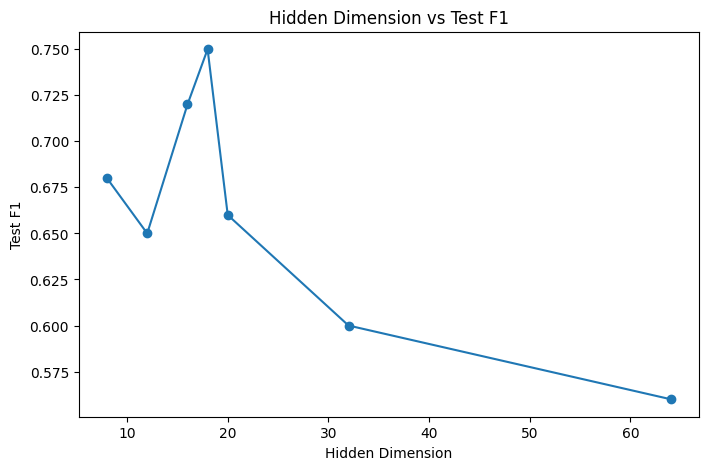

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(hidden_dims, test_f1s, marker='o')
plt.xlabel("Hidden Dimension")
plt.ylabel("Test F1")
plt.title("Hidden Dimension vs Test F1")
plt.grid(False)
plt.show()

## Results

In [ ]:
results_df = pd.DataFrame({
    "Metric": [
        "Features",
        "Model Name",
        "Feature Extract",
        "Method",
        "Hidden Dim",
        "Epochs",
        "Learning Rate",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC",
    ],

    "Logistic Regression": [
        str(features_to_extract),
        model.getName(),
        feature_to_extract,
        "LR",
        "-",
        "-",
        "-",
        metrics["lr_accuracy"],
        metrics["lr_precision"],
        metrics["lr_recall"],
        metrics["lr_f1"],
        metrics["lr_roc_auc"],
        metrics["lr_pr_auc"],
    ],

    "Simple Dense NN": [
        str(features_to_extract),
        model.getName(),
        feature_to_extract,
        "NN",
        hidden_dim,
        num_epochs,
        0.001,
        test_metrics["Accuracy"],
        test_metrics["Precision"],
        test_metrics["Recall"],
        test_metrics["F1"],
        test_metrics["ROC AUC"],
        test_metrics["PR AUC"],
    ]
})

display(results_df)

,Metric,Logistic Regression,Simple Dense NN
0,Features,"{'mtp': True, 'avgtp': True, 'MDVTP': True, 'M...","{'mtp': True, 'avgtp': True, 'MDVTP': True, 'M..."
1,Model Name,gpt2-large,gpt2-large
2,Feature Extract,all,all
3,Method,LR,NN
4,Hidden Dim,-,20
5,Epochs,-,100
6,Learning Rate,-,0.001
7,Accuracy,0.65625,0.59375
8,Precision,0.619048,0.565217
9,Recall,0.8125,0.8125
